## Shape Detection

In [1]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
image = cv2.imread("../data/test_images/shape.jpg")

gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

_,thresh = cv2.threshold(gray,127,255,0)

In [3]:
contours,_ = cv2.findContours(
    thresh,
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_SIMPLE
)

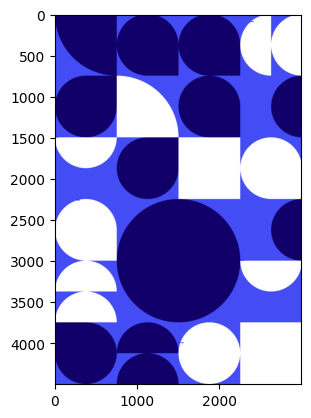

In [4]:
for contour in contours:
    approx = cv2.approxPolyDP(
        contour,
        0.01 * cv2.arcLength(contour,True),
        True
    )
    x = approx.ravel()[0]
    y = approx.ravel()[1]

    if len(approx) == 3:
        shape = "Triangle"
    elif len(approx) == 4:
        shape = "Rectangle"
    
    else:
        shape = "Circle"

    cv2.putText(
        image,
        shape,
        (x,y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255,0,0),
        2
    )

plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))